# Exploratory Data Analysis

In [11]:
# Import packages
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re

## Part1. Cases Dataset

### 1.1 Data overview

In [12]:
# Read the data
cases = pd.read_csv("cases_cleaned.csv")
cases.head(5)

,case_id,title,category,risk_level,setting,date,location,injury_category,severity,primary_classification,...,what_could_have_happened,root_causes,causal_factors,what_went_well,lessons,actions_raw,raw_block,country,setting_primary,setting_bucket
0,1,Minor Vapor Release During Instrument Tubing R...,Safety,Medium,Chemical processing unit – general operations ...,2019,Canada,No Injury,Potentially Significant,Health and Safety,...,● Vapor cloud accumulation in a low-ventilatio...,● Isolation plan assumed the transmitter’s sec...,● Time pressure to finish tasks before a sched...,● Technician immediately stopped work and re-s...,● Treat all small-bore tubing as pressure-reta...,1. Action: Add explicit vent-point check to al...,Title: Minor Vapor Release During Instrument T...,Canada,Chemical processing unit,Industrial Operations
1,2,Unexpected Pressure Release During Sampling Li...,Safety,Medium,Utilities area – process sampling station,2021,USA,No Injury,Potentially Significant,Health and Safety,...,● Accumulation of warm vapor leading to therma...,● Isolation plan did not consider trapped flui...,● Crews relied on verbal confirmation rather t...,"● Technician backed away immediately, demonstr...",● Always verify vent paths for all small-bore ...,1. Action: Add mandatory trapped-volume assess...,Title: Unexpected Pressure Release During Samp...,USA,Utilities area,Utilities & Infrastructure
2,3,Vapor Release During Transfer Hose Connection ...,Safety,Medium,Chemical unloading bay at a mid-scale processi...,2023,Canada,Medical Treatment,Potentially Significant,Health and Safety,...,● Inhalation of a higher concentration of vapo...,● Isolation procedure did not include a mandat...,● Time pressure due to several totes scheduled...,● Stop-work authority used immediately.\n● Ven...,● Always confirm venting and draining of lines...,1\nAction: Add a vent-verification step to all...,Title: Vapor Release During Transfer Hose Conn...,Canada,Chemical unloading bay at a mid,Industrial Operations
3,4,Inhalation Exposure During Acid Dilution Setup,Safety,Medium,Quality Control Laboratory – Wet Chemistry Area,2022,Canada,Medical Treatment,Potentially Significant,Health and Safety,...,● Higher-dose inhalation leading to respirator...,● Laboratory ventilation standards did not spe...,● Technician focused on glassware placement an...,● Technician recognized symptoms early and ste...,● Always fully lower fume-hood sash to the ope...,1. Action: Add explicit “operational sash heig...,Title: Inhalation Exposure During Acid Dilutio...,Canada,Quality Control Laboratory,Laboratories & Testing
4,5,Solvent Transfer Splash During Sample Prep,Safety,Medium,Analytical Laboratory – Organic Sample Prep Bench,2021,Canada,First Aid,Potentially Significant,Health and Safety,...,● Solvent spray could have contacted the techn...,● No standardized setup for solvent-transfer t...,● Bench clutter reduced maneuverability and cr...,● Technician reacted quickly and used immediat...,● Establish defined bench layouts and minimum ...,1. Action: Create a standard solvent-dispensin...,Title: Solvent Transfer Splash During Sample P...,Canada,Analytical Laboratory,Laboratories & Testing


### 1.2 Risk level distribution

In [13]:
cases["risk_level"].value_counts()

,count
risk_level,
High,129
Medium,66
Low,1


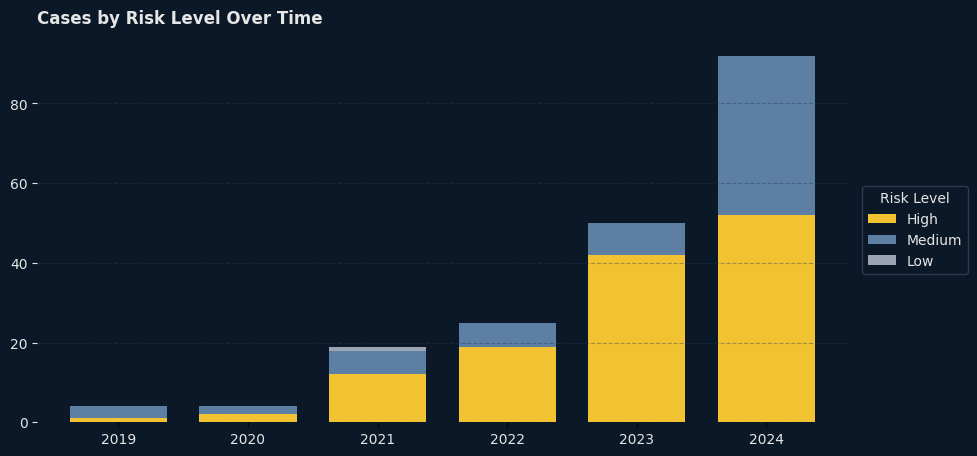

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Clean year ---
cases_clean = cases.dropna(subset=["date", "risk_level"]).copy()
cases_clean["date"] = pd.to_numeric(cases_clean["date"], errors="coerce")
cases_clean = cases_clean.dropna(subset=["date"])
cases_clean = cases_clean[cases_clean["date"] >= 2015]
cases_clean["date"] = cases_clean["date"].astype(int)

# --- Crosstab: Year x Risk ---
risk_year = pd.crosstab(cases_clean["date"], cases_clean["risk_level"])
risk_order = ["High", "Medium", "Low"]
risk_year = risk_year.reindex(columns=risk_order, fill_value=0).sort_index()

# --- Style ---
bg = "#0a1827"
text_c = "#E6E6E6"
grid_c = "#2a3b52"

colors = {
    "High":   "#f1c232",  # highlight
    "Medium": "#5C7FA3",  # steel blue
    "Low":    "#9aa4b2"   # muted grey
}

fig, ax = plt.subplots(figsize=(12, 5), facecolor=bg)
ax.set_facecolor(bg)

risk_year.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=[colors[c] for c in risk_order],
    width=0.75,
    legend=False
)

# Title (bold + left)
ax.set_title(
    "Cases by Risk Level Over Time",
    loc="left",
    color=text_c,
    fontsize=12,
    fontweight="bold",
    pad=10
)

# No axis titles
ax.set_xlabel("")
ax.set_ylabel("")

# Ticks
ax.set_xticklabels([str(int(x)) for x in risk_year.index], rotation=0, color=text_c)
ax.tick_params(axis="y", colors=text_c)

# Grid + spines
ax.yaxis.grid(True, color=grid_c, linestyle="--", alpha=0.4)
ax.xaxis.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

# Legend outside (reserve margin)
handles, labels = ax.get_legend_handles_labels()
fig.subplots_adjust(right=0.80)

leg = ax.legend(
    handles, labels,
    title="Risk Level",
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=True
)
plt.setp(leg.get_texts(), color=text_c)
plt.setp(leg.get_title(), color=text_c)
leg.get_frame().set_facecolor(bg)
leg.get_frame().set_edgecolor(grid_c)
leg.get_frame().set_alpha(1)

plt.show()

The post-2021 rise in incident reports is mainly driven by high- and medium-risk cases and is likely influenced by enhanced reporting practices and increased employee participation in incident reporting. However, it is important to note that the dataset has been manually curated to exclude sensitive or identifiable information, which may introduce selection bias and limit the representativeness of the data.

### 1.3 Severity distribution

/tmp/ipython-input-3591125043.py:28: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt = pd.to_datetime(s, errors="coerce", infer_datetime_format=True)


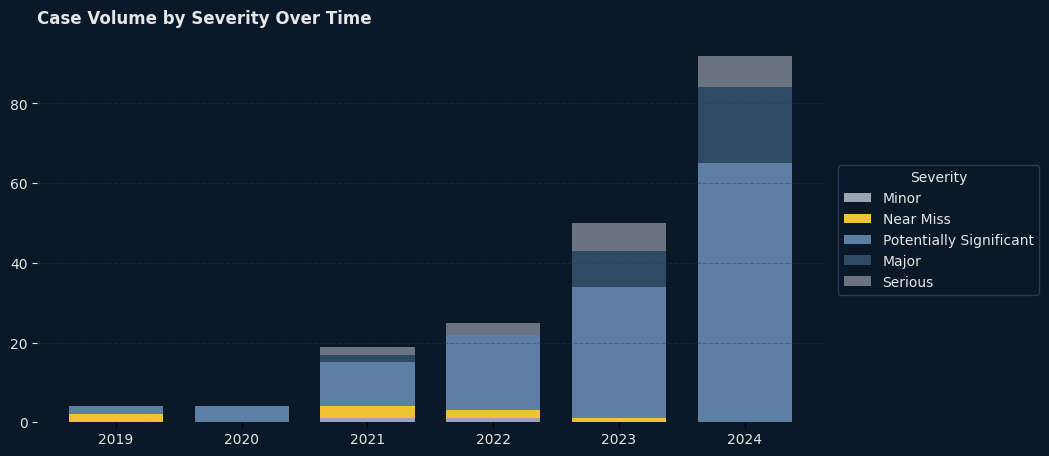

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# STYLE (match your deck)
# -----------------------------
bg = "#0a1827"
text_c = "#E6E6E6"
grid_c = "#2a3b52"

# Highlight Near Miss, mute others
severity_colors = {
    "Minor": "#9aa4b2",                   # muted grey
    "Near Miss": "#f1c232",               # highlight yellow
    "Potentially Significant": "#5C7FA3", # steel blue
    "Major": "#2F4A63",                   # navy
    "Serious": "#6b7280"                  # dark muted grey
}

severity_order = ["Minor", "Near Miss", "Potentially Significant", "Major", "Serious"]

# -----------------------------
# Robust year extraction
# -----------------------------
s = cases_clean["date"].astype(str)

dt = pd.to_datetime(s, errors="coerce", infer_datetime_format=True)
year_dt = dt.dt.year

year_rx = s.str.extract(r"((?:19|20)\d{2})", expand=False).astype("float")

year = year_dt.fillna(year_rx)
year = year[(year >= 1990) & (year <= 2035)].astype(int)

cases_tmp = cases_clean.loc[year.index].copy()
cases_tmp["year"] = year.values

# -----------------------------
# Crosstab: Year x Severity
# -----------------------------
pivot_df = pd.crosstab(cases_tmp["year"], cases_tmp["severity"])
pivot_df2 = (
    pivot_df
    .reindex(columns=severity_order, fill_value=0)
    .sort_index()
)

colors = [severity_colors[s] for s in severity_order]

# -----------------------------
# Plot: stacked bars only
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 5), facecolor=bg)  # wider so legend fits
ax.set_facecolor(bg)

pivot_df2.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors,
    width=0.75,
    legend=False  # we'll add custom legend outside
)

# Title (bold + left aligned)
ax.set_title(
    "Case Volume by Severity Over Time",
    loc="left",
    color=text_c,
    fontsize=12,
    fontweight="bold",
    pad=10
)

# No axis titles
ax.set_xlabel("")
ax.set_ylabel("")

# Year labels as integers
ax.set_xticklabels([str(int(x)) for x in pivot_df2.index], rotation=0, color=text_c)
ax.tick_params(axis="y", colors=text_c)

# Subtle grid
ax.yaxis.grid(True, color=grid_c, linestyle="--", alpha=0.4)
ax.xaxis.grid(False)

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

# -----------------------------
# Legend OUTSIDE (no overlap)
# -----------------------------
handles, labels = ax.get_legend_handles_labels()

# Reserve right margin and place legend in it
fig.subplots_adjust(right=0.78)

leg = ax.legend(
    handles,
    labels,
    title="Severity",
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=True
)

plt.setp(leg.get_texts(), color=text_c)
plt.setp(leg.get_title(), color=text_c)
leg.get_frame().set_facecolor(bg)
leg.get_frame().set_edgecolor(grid_c)
leg.get_frame().set_alpha(1)

plt.show()


### 1.4 Injury distribution

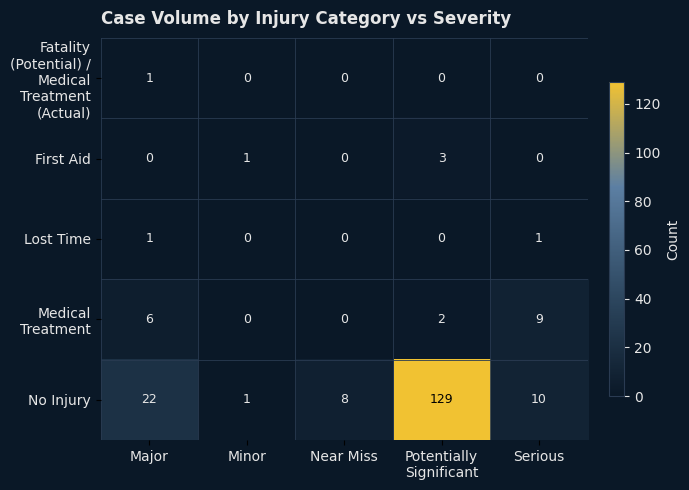

In [16]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import textwrap

bg = "#0a1827"
text_c = "#E6E6E6"
grid_c = "#2a3b52"

# Stronger contrast colormap (dark → yellow)
methanex_cmap = mcolors.LinearSegmentedColormap.from_list(
    "methanex_threshold",
    [
        "#0a1827",   # background dark
        "#2F4A63",   # navy
        "#5C7FA3",   # steel blue
        "#f1c232"    # yellow highlight
    ]
)

# Build heat table
heat = pd.crosstab(cases_clean["injury_category"], cases_clean["severity"])

# Wrap long labels into 2 rows
def wrap_label(s, width=14):
    return "\n".join(textwrap.wrap(str(s), width))

x_labels = [wrap_label(x) for x in heat.columns]
y_labels = [wrap_label(y) for y in heat.index]

plt.figure(figsize=(7,5), facecolor=bg)
ax = plt.gca()
ax.set_facecolor(bg)

im = ax.imshow(
    heat.values,
    aspect="auto",
    cmap=methanex_cmap
)

# Axis ticks (straight + readable)
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, color=text_c)
ax.set_yticks(range(len(y_labels)))
ax.set_yticklabels(y_labels, color=text_c)

# No axis titles
ax.set_xlabel("")
ax.set_ylabel("")

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Gridlines
ax.set_xticks(np.arange(-.5, heat.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-.5, heat.shape[0], 1), minor=True)
ax.grid(which="minor", color=grid_c, linestyle="-", linewidth=0.6)
ax.tick_params(which="minor", bottom=False, left=False)

# Annotate counts
mx = heat.values.max()
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat.values[i, j]

        # Default color logic
        txt_color = "white" if val > 0.35 * mx else text_c

        # Force black text for No Injury × Potentially Significant
        if heat.index[i] == "No Injury" and heat.columns[j] == "Potentially Significant":
            txt_color = "black"

        ax.text(
            j, i, int(val),
            ha="center",
            va="center",
            color=txt_color,
            fontsize=9
        )


# Title (bold + left aligned)
ax.set_title(
    "Case Volume by Injury Category vs Severity",
    loc="left",
    color=text_c,
    fontsize=12,
    fontweight="bold",
    pad=10
)

# Colorbar (dark theme)
cbar = plt.colorbar(im, fraction=0.03, pad=0.04)
cbar.ax.tick_params(colors=text_c)
cbar.outline.set_edgecolor(grid_c)
cbar.set_label("Count", color=text_c)

plt.tight_layout()
plt.show()

In [17]:
xx_pct = (
    (cases_clean["severity"].isin(["Major", "Serious"])) &
    (cases_clean["injury_category"] == "No Injury")
).sum() / (cases_clean["severity"].isin(["Major", "Serious"])).sum() * 100
print("About " + str(xx_pct) + "% of our major and serious cases do not have any injury.")

About 64.0% of our major and serious cases do not have any injury.


### 1.5 Location distribution

In [18]:
cases["country"].value_counts()

,count
country,
Canada,150
Remote,16
Trinidad & Tobago,13
USA,11
Chile,3
New Zealand,1
Belgium,1
Egypt,1


## Part2. Actions Dataset Overview

### 2.1 Data overview

In [19]:
actions = pd.read_csv("cleaned_actions.csv")

actions.head(5)

,action_id,action_text,owner_raw,timing_raw,verification_text,case_id,title,timing_raw_clean,owner_bucket,action_type,control_level,timing_norm
0,1,Add explicit vent-point check to all transmitt...,Maintenance Planner,<30 days,Spot audit of next 10 relevant jobs.,1,Minor Vapor Release During Instrument Tubing R...,<30 days,Maintenance,Equipment/Engineering Change,Engineering control,<30 days
1,2,Install high-visibility tags on local instrume...,Operations Supervisor,30–90 days,Field walkdown signoff.,1,Minor Vapor Release During Instrument Tubing R...,30–90 days,Operations,Equipment/Engineering Change,Engineering control,30-90 days
2,3,Update isolation standard to include guidance ...,Process Safety Engineer,>90 days,Procedure approval plus training record review.,1,Minor Vapor Release During Instrument Tubing R...,>90 days,HSE,Procedure/Standard,Administrative control,>90 days
3,4,Conduct refresher training on identifying pres...,HSE Advisor,<30 days,Attendance log & post-training quiz.,1,Minor Vapor Release During Instrument Tubing R...,<30 days,HSE,Training/Drills,Administrative control,<30 days
4,5,"Implement mandatory ""vent-verified"" checkbox o...",Permit to Work Coordinator,Immediate,Weekly PTW compliance review.,1,Minor Vapor Release During Instrument Tubing R...,Immediate,Facilities/Field,Procedure/Standard,Administrative control,Immediate


### 2.2 Actions per incidents

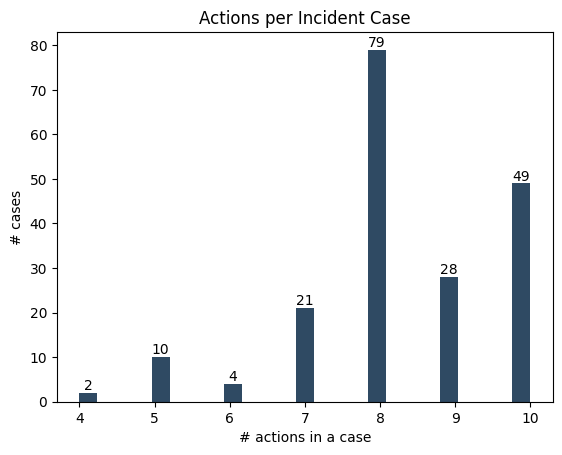

In [20]:
actions_per_case = actions.groupby("case_id").size()

plt.figure()
n, bins, patches = plt.hist(actions_per_case, bins=25, color="#2F4A63")

# Add counts on top of each bar
for count, bin_edge, patch in zip(n, bins, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            patch.get_height(),
            int(count),                          # The count value
            ha='center',
            va='bottom'
        )

plt.title("Actions per Incident Case")
plt.xlabel("# actions in a case")
plt.ylabel("# cases")
plt.show()

### 2.3 Action Types

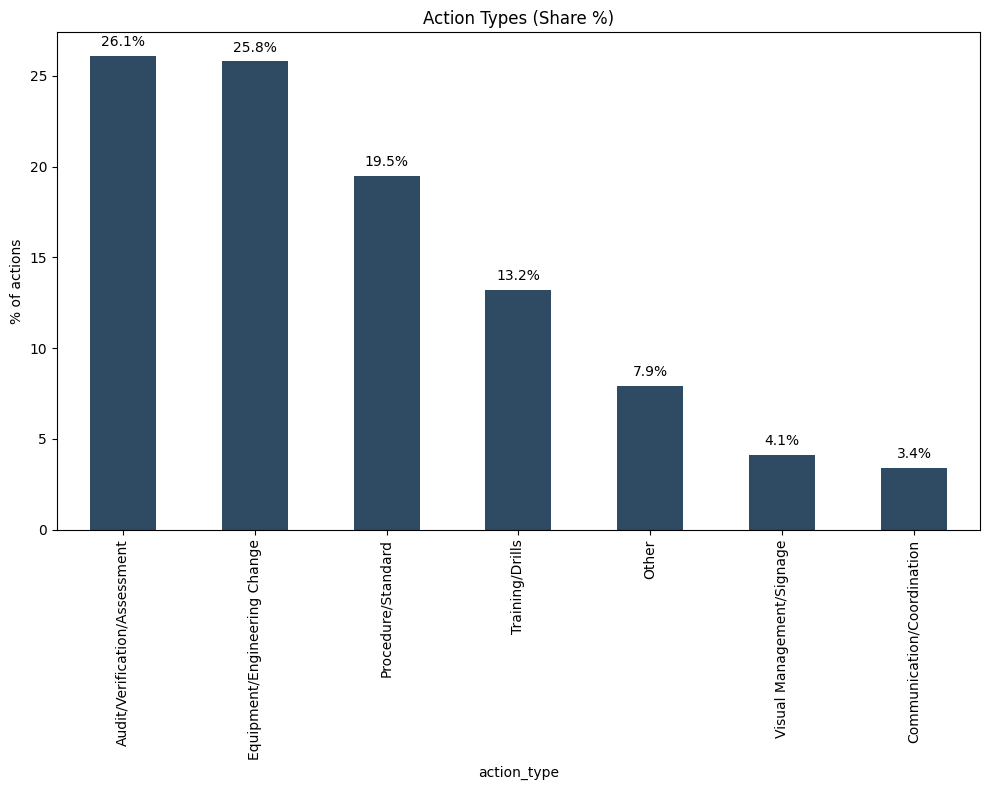

In [21]:
# Get raw counts for annotation
type_counts = actions["action_type"].value_counts()
type_share = (type_counts / type_counts.sum() * 100).round(1)

plt.figure(figsize=(10, 8))
ax = type_share.plot(kind="bar", color="#2F4A63")

# Add only percentage on top of each bar
for i, p in enumerate(ax.patches):
    percentage = type_share.iloc[i]
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

plt.title("Action Types (Share %)")
plt.xlabel("action_type")
plt.ylabel("% of actions")
plt.tight_layout() # Re-adding tight layout
plt.show()

### 2.4 Actions control level

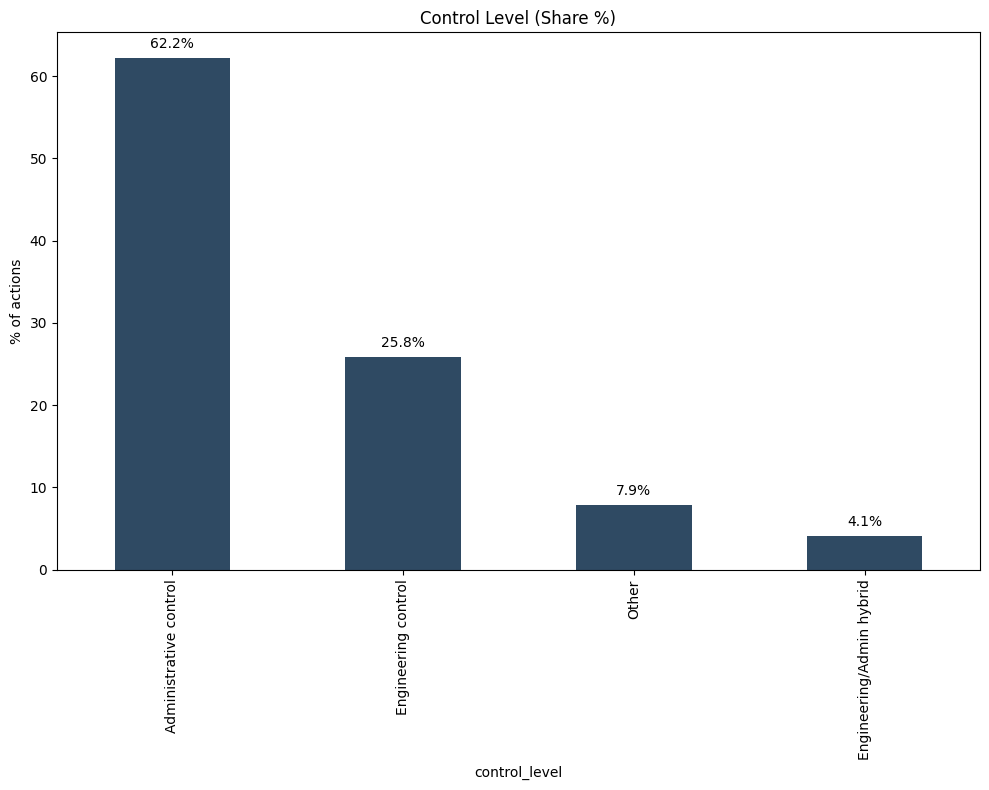

In [22]:
ctrl_share = (actions["control_level"].value_counts(normalize=True) * 100).round(1)

plt.figure(figsize=(10, 8))
ax = ctrl_share.plot(kind="bar",color="#2F4A63")

# Add percentage on top of each bar
for i, p in enumerate(ax.patches):
    percentage = ctrl_share.iloc[i]
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

plt.title("Control Level (Share %)")
plt.xlabel("control_level")
plt.ylabel("% of actions")
plt.tight_layout()
plt.show()

### 2.5 Actions timing buckets

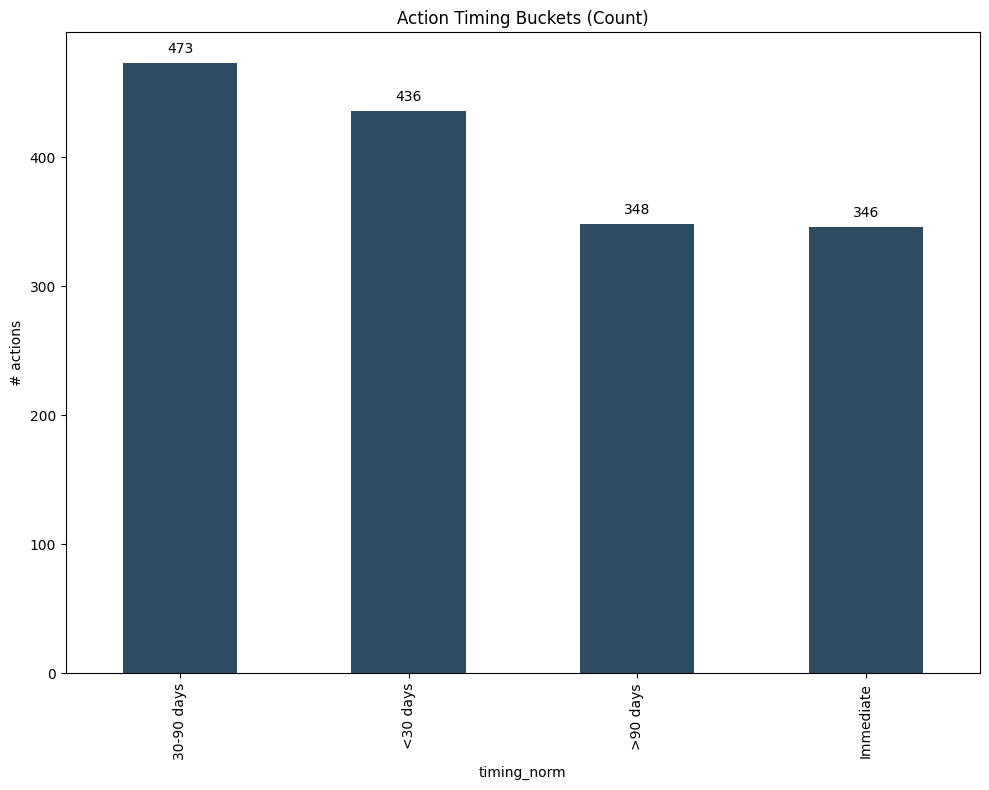

In [23]:
timing_counts = actions["timing_norm"].value_counts()

plt.figure(figsize=(10, 8))
ax = timing_counts.plot(kind="bar",color="#2F4A63")

# Add count on top of each bar
for i, p in enumerate(ax.patches):
    count_val = p.get_height()
    ax.annotate(f'{int(count_val)}',
                (p.get_x() + p.get_width() / 2., count_val),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

plt.title("Action Timing Buckets (Count)")
plt.xlabel("timing_norm")
plt.ylabel("# actions")
plt.tight_layout()
plt.show()

### 2.6 Actions verifications

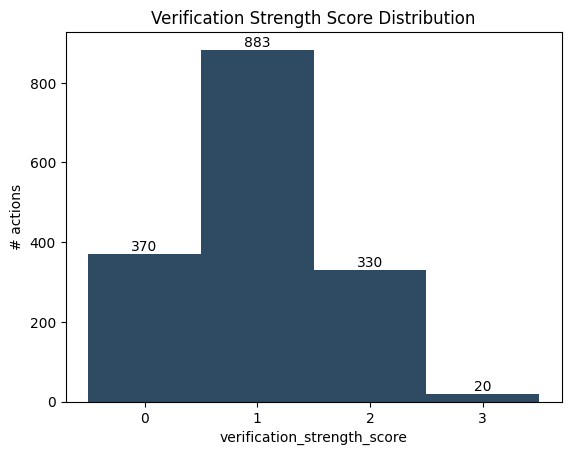

In [24]:
# Derived verification-strength features by detecting whether audits/logs/tests were mentioned.
# (strength = How objectively completion is checked)
def calculate_verification_strength(text):
    score = 0
    if not isinstance(text, str): # Handle non-string values
        return 0
    lower_text = text.lower()
    if re.search(r'audit|inspection|review', lower_text): score += 1
    if re.search(r'log|record|data|report', lower_text): score += 1
    if re.search(r'test|validate|demonstrate|confirm', lower_text): score += 1
    return score

actions["verification_strength_score"] = actions["verification_text"].apply(calculate_verification_strength)

plt.figure()
n, bins, patches = plt.hist(actions["verification_strength_score"].fillna(0), bins=[-0.5,0.5,1.5,2.5,3.5],color="#2F4A63")

# Add counts on top of each bar
for count, bin_edge, patch in zip(n, bins, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width() / 2, # X-coordinate (center of the bar)
            patch.get_height(),                  # Y-coordinate (top of the bar)
            int(count),                          # The count value
            ha='center',                         # Horizontal alignment
            va='bottom'                          # Vertical alignment
        )

plt.title("Verification Strength Score Distribution")
plt.xlabel("verification_strength_score")
plt.ylabel("# actions")
plt.xticks([0,1,2,3])
plt.show()

## Part3. Problems found with joint datasets

In [25]:
df = actions.merge(
    cases[["case_id","severity","category","setting","location"]],
    on="case_id",
    how="left")

### 1. Methanex is systematically treating symptoms rather than eliminating hazards

In [26]:
control_order = [
    "Administrative control",
    "Engineering control",
    "Engineering/Admin hybrid",
    "Other"
]

colors = [
    "#2F4A63",  # Administrative control (navy)
    "#F2B705",  # Engineering control (gold)
    "#5C7FA3",  # Engineering/Admin hybrid (steel blue)
    "#DDE3EA"   # Other (brick red)
]

<Figure size 1200x800 with 0 Axes>

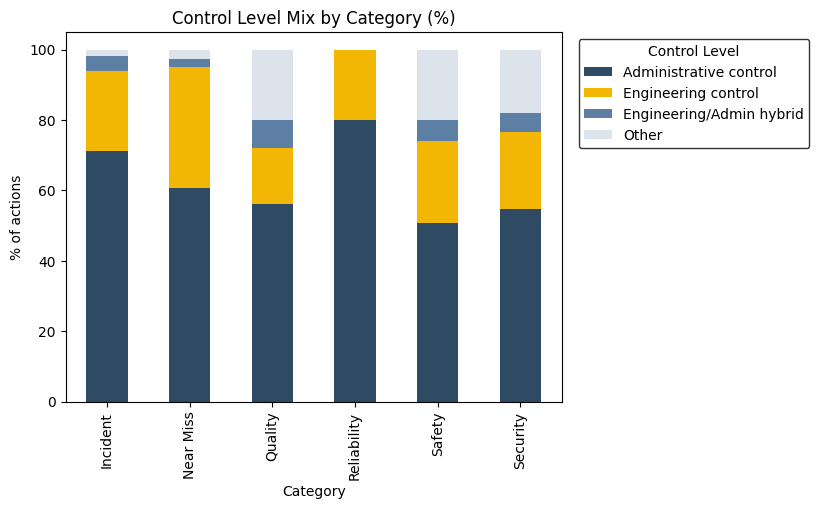

In [27]:
ctrl_by_cat = (
    pd.crosstab(df["category"], df["control_level"], normalize="index") * 100
)

# enforce column order
ctrl_by_cat = ctrl_by_cat.reindex(columns=control_order)

plt.figure(figsize=(12, 8))
ctrl_by_cat.plot(
    kind="bar",
    stacked=True,
    color=colors
)

plt.title("Control Level Mix by Category (%)")
plt.ylabel("% of actions")
plt.xlabel("Category")

plt.legend(
    title="Control Level",
    bbox_to_anchor=(1.02, 1),
    frameon=True,
    facecolor="white",
    edgecolor="black"
)

plt.show()


* Administrative controls dominate responses across all categories, which may indicate that cases are not always asigned to the most effective control owners. While administrative actions are faster to deploy, their distance from the physical scene may limit their ability to address root causes, particularly for quality, reliability, and safety issues that would benefit from stronger engineering control.

### 2. Near Misses get weakest verification and least long-term action

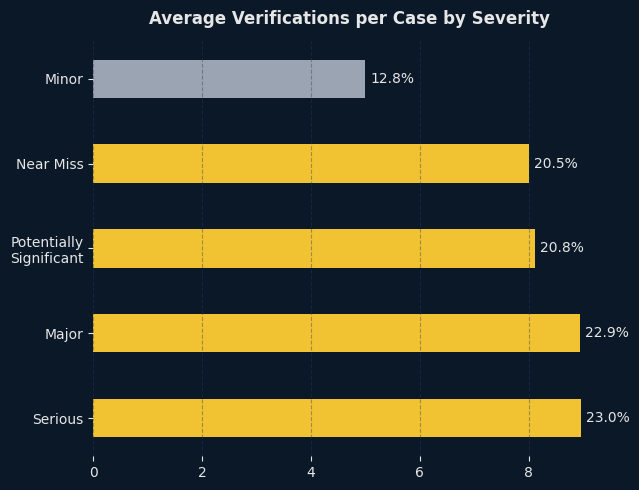

In [28]:
bg = "#0a1827"
highlight = "#f1c232"
muted = "#9aa4b2"
text_color = "#E6E6E6"
grid_color = "#2a3b52"

# Make sure verification_text is string and not empty
df["has_verification"] = df["verification_text"].notna() & (df["verification_text"].astype(str).str.strip() != "")

case_verification = (
    df.groupby("case_id")
      .agg(
          severity=("severity", "first"),
          verification_count=("has_verification", "sum"),
          n_actions=("action_id", "count")
      )
      .reset_index()
)

sev_verif_summary = (
    case_verification
    .groupby("severity")["verification_count"]
    .mean()
    .reindex(["Minor", "Near Miss", "Potentially Significant", "Major", "Serious"])
)

# Force 2-line label
sev_verif_summary = sev_verif_summary.rename(
    index={"Potentially Significant": "Potentially\nSignificant"}
)

sev_plot = sev_verif_summary[::-1]

highlight_ones = ["Near Miss", "Potentially\nSignificant", "Major", "Serious"]

colors = [
    highlight if idx in highlight_ones else muted
    for idx in sev_plot.index
]

plt.figure(figsize=(6.5,5), facecolor=bg)   # narrower width
ax = plt.gca()
ax.set_facecolor(bg)

bars = ax.barh(
    sev_plot.index,
    sev_plot.values,
    color=colors,
    height=0.45
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="both", colors=text_color, labelsize=10)

ax.xaxis.grid(True, color=grid_color, linestyle="--", alpha=0.4)
ax.yaxis.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

total = sev_plot.sum()

for bar, val in zip(bars, sev_plot.values):
    pct = val / total * 100
    ax.text(
        val + 0.1,
        bar.get_y() + bar.get_height()/2,
        f"{pct:.1f}%",
        va="center",
        ha="left",
        color=text_color,
        fontsize=10
    )

ax.set_title(
    "Average Verifications per Case by Severity",
    color=text_color,
    fontsize=12,
    fontweight="bold",
    pad=12
)

plt.tight_layout()
plt.show()

* While verification activity increases with severity, the pattern appears largely proportional to the number of actions rather than risk intensity. This suggests that verification may function as a procedural requirement attached to each action, rather than a differentiated control mechanism that scales meaningfully with severity.
* Near miss cases, which serve as critical leading indicators of future incidents, do not receive higher verification attention compared to more severe cases.

In [35]:

# --- styling (match your slide) ---
bg = "#0a1827"
short_c = "#f1c232"   # highlight (short-term)
long_c  = "#9aa4b2"   # muted grey (long-term)
text_c  = "#E6E6E6"
grid_c  = "#2a3b52"

# Ensure consistent ordering + nicer labels
order = ["Minor", "Near Miss", "Potentially Significant", "Major", "Serious"]

sev_plot = (
    sev_timing
    .reindex(order)
    .rename(index={"Potentially Significant": "Potentially\nSignificant"})
)

sev_plot = sev_plot[::-1]

# --- plot: horizontal stacked bars ---
plt.figure(figsize=(6.8, 5), facecolor=bg)  # narrower width like your other chart
ax = plt.gca()
ax.set_facecolor(bg)

y = sev_plot.index
short_vals = sev_plot["pct_short"].values
long_vals  = sev_plot["pct_long"].values

bar_h = 0.45  # slimmer bars

ax.barh(y, short_vals, color=short_c, height=bar_h, label="Short-term actions")
ax.barh(y, long_vals,  left=short_vals, color=long_c, height=bar_h, label="Long-term actions")

# Remove axis titles
ax.set_xlabel("")
ax.set_ylabel("")

# Tick styling
ax.tick_params(axis="both", colors=text_c, labelsize=10)

# Subtle x-grid only
ax.xaxis.grid(True, color=grid_c, linestyle="--", alpha=0.4)
ax.yaxis.grid(False)

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Bold title
ax.set_title(
    "Short vs Long Term Actions by Severity (Case Level)",
    loc="left",          # <<< aligns to plot area
    color=text_c,
    fontsize=12,
    fontweight="bold",
    pad=12
)

# Legend (dark theme)
leg = ax.legend(
    title="Action Type",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),   # push legend outside
    frameon=True)

plt.setp(leg.get_texts(), color=text_c)
plt.setp(leg.get_title(), color=text_c)
leg.get_frame().set_facecolor(bg)
leg.get_frame().set_edgecolor(grid_c)
leg.get_frame().set_alpha(1)

plt.tight_layout()
plt.show()


NameError: name 'sev_timing' is not defined

* Across every severity category, short-term actions dominate the majority of responses. This indicates that the organization tends to prioritize immediate actions and quick fixes when incidents occur, regardless of how severe the case is.
* Notably, even near miss cases, which are widely recognized as leading indicators of more serious incidents are predominantly handled through short-term measures rather than long-term corrective actions.
* This suggests that these early warning signals may not be fully leveraged for prevention. As a result, the overall response strategy appears more reactive than preventive, and the underlying root causes may not always be thoroughly addressed.

### 3. Corrective actions lack consistency and institutional memory

In [ ]:
# Data prep
action_mix = (
    pd.crosstab(df["category"], df["action_type"], normalize="index") * 100
)

# Methanex continuous colormap
# Minor -> Near Miss -> Major
methanex_cmap = mcolors.LinearSegmentedColormap.from_list(
    "methanex_actions",
    [
        "#DDE3EA",  # light grey (low %)
        "#F2B705",  # yello (mid %)
        "#2f4A63",  # navy (high %)
    ]
)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(
    action_mix.values,
    aspect="auto",
    cmap=methanex_cmap,
    vmin=0,
    vmax=40
)

# Axes
ax.set_yticks(range(action_mix.shape[0]))
ax.set_yticklabels(action_mix.index)

ax.set_xticks(range(action_mix.shape[1]))
ax.set_xticklabels(action_mix.columns, rotation=45, ha="right")

ax.set_title("Action Type Distribution by Category")
ax.set_xlabel("Action Type")
ax.set_ylabel("Category")

# Annotate percentages (clean, readable)
for i in range(action_mix.shape[0]):
    for j in range(action_mix.shape[1]):
        val = action_mix.values[i, j]
        ax.text(
            j, i, f"{val:.1f}",
            ha="center", va="center",
            color="white" if val > 50 else "black",
            fontsize=9
        )

# Colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("% of Actions")

plt.tight_layout()
plt.show()

* Action patterns vary widely across categories—such as audits dominating reliability cases, suggesting the absence of a standardized response playbook. As a result, teams often design corrective actions on a case-by-case basis, resulting in a low consistency and effciency manner.

### 4. High-risk cases consist with longer-period solution period, instead of immediate solution.

In [30]:
# -----------------------------
# Horizontal stacked bars with % labels
# -----------------------------

bg = "#0a1827"
text_c = "#E6E6E6"
grid_c = "#2a3b52"

# Rename columns for legend clarity
risk_plot = heatmap_prep.rename(columns={
    "Immediate": "Immediate",
    "<30": "<30 days",
    "30-90": "30–90 days",
    ">90": ">90 days"
})

timing_colors = {
    "Immediate": "#9aa4b2",
    "<30 days": "#5C7FA3",
    "30–90 days": "#f1c232",   # highlight
    ">90 days": "#6b7280"
}

fig, ax = plt.subplots(figsize=(7.4, 4.2), facecolor=bg)
ax.set_facecolor(bg)

left = np.zeros(len(risk_plot))

for col in risk_plot.columns:
    bars = ax.barh(
        risk_plot.index,
        risk_plot[col],
        left=left,
        color=timing_colors[col],
        height=0.5,
        label=col
    )

    # ---- % labels inside each segment ----
    for bar, val in zip(bars, risk_plot[col].values):
        if val >= 6:  # avoid clutter on tiny segments
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_y() + bar.get_height()/2,
                f"{val:.1f}%",
                ha="center",
                va="center",
                color="black" if col == "30–90 days" else text_c,
                fontsize=9
            )

    left += risk_plot[col].values

# Title
ax.set_title(
    "Risk Level vs Implementation Urgency",
    loc="left",
    color=text_c,
    fontsize=12,
    fontweight="bold",
    pad=10
)

# Clean axes
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", colors=text_c)
ax.tick_params(axis="y", colors=text_c)

ax.xaxis.grid(True, color=grid_c, linestyle="--", alpha=0.4)
ax.yaxis.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

# Legend outside
fig.subplots_adjust(right=0.78)

leg = ax.legend(
    title="Timing Bucket",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.20),   # below chart
    ncol=2,                       # <<< 2 columns = 2 rows
    frameon=True
)

plt.setp(leg.get_texts(), color=text_c)
plt.setp(leg.get_title(), color=text_c)
leg.get_frame().set_facecolor(bg)
leg.get_frame().set_edgecolor(grid_c)

# Make room underneath
plt.subplots_adjust(bottom=0.28)

NameError: name 'heatmap_prep' is not defined

1. Look at the Immediate column. There is only a 1.9% difference between High and Medium risk. This means historically, Methanex treats a high-risk explosion hazard with almost the same administrative urgency as a medium-risk maintenance issue.

2. The "30-90 Day" Trap, nearly 30% of all High-Risk actions are stuck in the 30-90 day bucket. This is the "Danger Zone"—the company has identified a critical risk, but the solution is sitting in a queue for 1 to 3 months.

# Part4. Data Limitations

* The post-2021 increase in reporting has resulted in an imbalanced dataset, with high-risk cases and medium-risk cases being over represented. This imbalance may influence subsequent clustering results, potentially limiting the ability to identify underlying incident patterns in a representative way.
* The dataset is geographically concentrated, with the majority of cases originating from Canada. This imbalance limits the generalizability of findings across different countries and may reflect location-specific reporting incidents, regulatory environments, or operational conditions. As a result, our model or application might not work very well in other countries without tuning or additional data.